In [1]:
import pandas as pd
import numpy as np
import pickle, warnings, datetime
import matplotlib.pyplot as plt
import seaborn as sns
from great_tables import GT, md, html, style, loc
warnings.filterwarnings('ignore')

In [2]:
# Read pickle file containing the DataFrame
# Ensure the path is correct and the file exists
path = '../../Data/Processed/merged_data_finance.pkl'
with open(path, 'rb') as file:
    df = pickle.load(file)

In [3]:
df

,date,ticker,Article Count_cum04_lag01,Article Count_cum16_lag01,Article Count_cum48_lag01,Article Count_cum96_lag01,Article Count_lag01,BNO_Change_High-Low,BNO_Change_High-Low_lag01,BNO_Change_High-Low_ma04,...,v42.8; SCOREDVALUE; fairness_sent_cum04_lag01,v42.8; SCOREDVALUE; fairness_sent_cum16_lag01,v42.8; SCOREDVALUE; fairness_sent_cum48_lag01,v42.8; SCOREDVALUE; fairness_sent_cum96_lag01,v42.8; SCOREDVALUE; fairness_sent_lag01,v42.9; SCOREDVALUE; loyalty_sent_cum04_lag01,v42.9; SCOREDVALUE; loyalty_sent_cum16_lag01,v42.9; SCOREDVALUE; loyalty_sent_cum48_lag01,v42.9; SCOREDVALUE; loyalty_sent_cum96_lag01,v42.9; SCOREDVALUE; loyalty_sent_lag01
0,2018-01-02 09:45:00,AAL,1,6,6,6,0,-0.035,0.020,0.01000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
1,2018-01-02 09:45:00,ALGT,0,0,0,0,0,-0.035,0.020,0.01000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
2,2018-01-02 09:45:00,ALK,0,3,5,5,0,-0.035,0.020,0.01000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
3,2018-01-02 09:45:00,DAL,0,1,1,1,0,-0.035,0.020,0.01000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
4,2018-01-02 09:45:00,JBLU,1,3,3,3,0,-0.035,0.020,0.01000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337783,2025-05-30 15:45:00,ALK,0,0,4,13,0,-0.020,0.015,0.00875,...,0.0,0.000000,-0.139706,-0.133636,0.0,0.0,0.000000,-0.067318,0.075841,0.0
337784,2025-05-30 15:45:00,DAL,0,4,7,11,0,-0.020,0.015,0.00875,...,0.0,-0.039292,0.056338,-0.185764,0.0,0.0,0.065506,0.186295,0.109351,0.0
337785,2025-05-30 15:45:00,JBLU,0,2,5,20,0,-0.020,0.015,0.00875,...,0.0,0.013177,0.021646,0.389782,0.0,0.0,0.052000,0.107777,0.615597,0.0
337786,2025-05-30 15:45:00,LUV,0,0,1,11,0,-0.020,0.015,0.00875,...,0.0,0.000000,0.028658,-0.189179,0.0,0.0,0.000000,0.042602,0.175897,0.0


In [4]:
sentiment_cols = [i for i in df.columns if any(x in i for x in ['Article Count', 'Tone', 'llm'])] + [i for i in df.columns if i.startswith('c') or i.startswith('v')]
sentiment_cols

['Article Count_cum04_lag01',
 'Article Count_cum16_lag01',
 'Article Count_cum48_lag01',
 'Article Count_cum96_lag01',
 'Article Count_lag01',
 'Tone_cum04_lag01',
 'Tone_cum16_lag01',
 'Tone_cum48_lag01',
 'Tone_cum96_lag01',
 'Tone_lag01',
 'llm_dimension_00_cum04_lag01',
 'llm_dimension_00_cum16_lag01',
 'llm_dimension_00_cum48_lag01',
 'llm_dimension_00_cum96_lag01',
 'llm_dimension_00_lag01',
 'llm_dimension_01_cum04_lag01',
 'llm_dimension_01_cum16_lag01',
 'llm_dimension_01_cum48_lag01',
 'llm_dimension_01_cum96_lag01',
 'llm_dimension_01_lag01',
 'llm_dimension_02_cum04_lag01',
 'llm_dimension_02_cum16_lag01',
 'llm_dimension_02_cum48_lag01',
 'llm_dimension_02_cum96_lag01',
 'llm_dimension_02_lag01',
 'llm_dimension_03_cum04_lag01',
 'llm_dimension_03_cum16_lag01',
 'llm_dimension_03_cum48_lag01',
 'llm_dimension_03_cum96_lag01',
 'llm_dimension_03_lag01',
 'llm_dimension_04_cum04_lag01',
 'llm_dimension_04_cum16_lag01',
 'llm_dimension_04_cum48_lag01',
 'llm_dimension_04_cum

In [5]:
# Summary statistics for Volume grouped by ticker
volume_summary = df.groupby('ticker')['Volume'].agg([
    ('Min.', 'min'),
    ('25%', lambda x: x.quantile(0.25)),
    ('50%', 'median'),
    ('Mean', 'mean'),
    ('Std.', 'std'),
    ('75%', lambda x: x.quantile(0.75)),
    ('Max.', 'max'),
    ('Skew', 'skew')
]).reset_index()

kurtosis = df[['ticker','Volume']].groupby('ticker').apply(pd.DataFrame.kurt)
volume_summary['Kurtosis'] = kurtosis.values
volume_summary['Coef. Var.'] = volume_summary['Std.'] / volume_summary['Mean']

# swap rows and columns
volume_summary = volume_summary.set_index('ticker').T

volume_summary['Statistic'] = volume_summary.index
# Reorder the columns
volume_summary = volume_summary[['Statistic'] + [col for col in volume_summary.columns if col != 'Statistic']]

# Create a GT table from the summary DataFrame
gt_table = GT(volume_summary)

gt_table = gt_table.fmt_number(columns=['AAL', 'ALGT', 'ALK', 'DAL', 'JBLU', 'LUV', 'UAL'], rows=list(range(7)), use_seps=True, decimals=0)
gt_table = gt_table.fmt_number(columns=['AAL', 'ALGT', 'ALK', 'DAL', 'JBLU', 'LUV', 'UAL'], rows=[7,8,9], use_seps=True, decimals=2)

# Add a title, subtitle, and source note
gt_table = gt_table.tab_header(
    title="Summary Statistics for 15-Minute Stock Volume",
    subtitle=f"All Stocks, Jan. 2018 to May 2025",
)

with open('../../output/summary_volume.tex', 'w') as f:
    f.write(gt_table.as_latex(tbl_pos="H").replace('caption*', 'caption').replace('{\large','{').replace(r'\fontsize{12.0pt}{14.4pt}\selectfont',r'\fontsize{10.0pt}{12pt}\selectfont'))

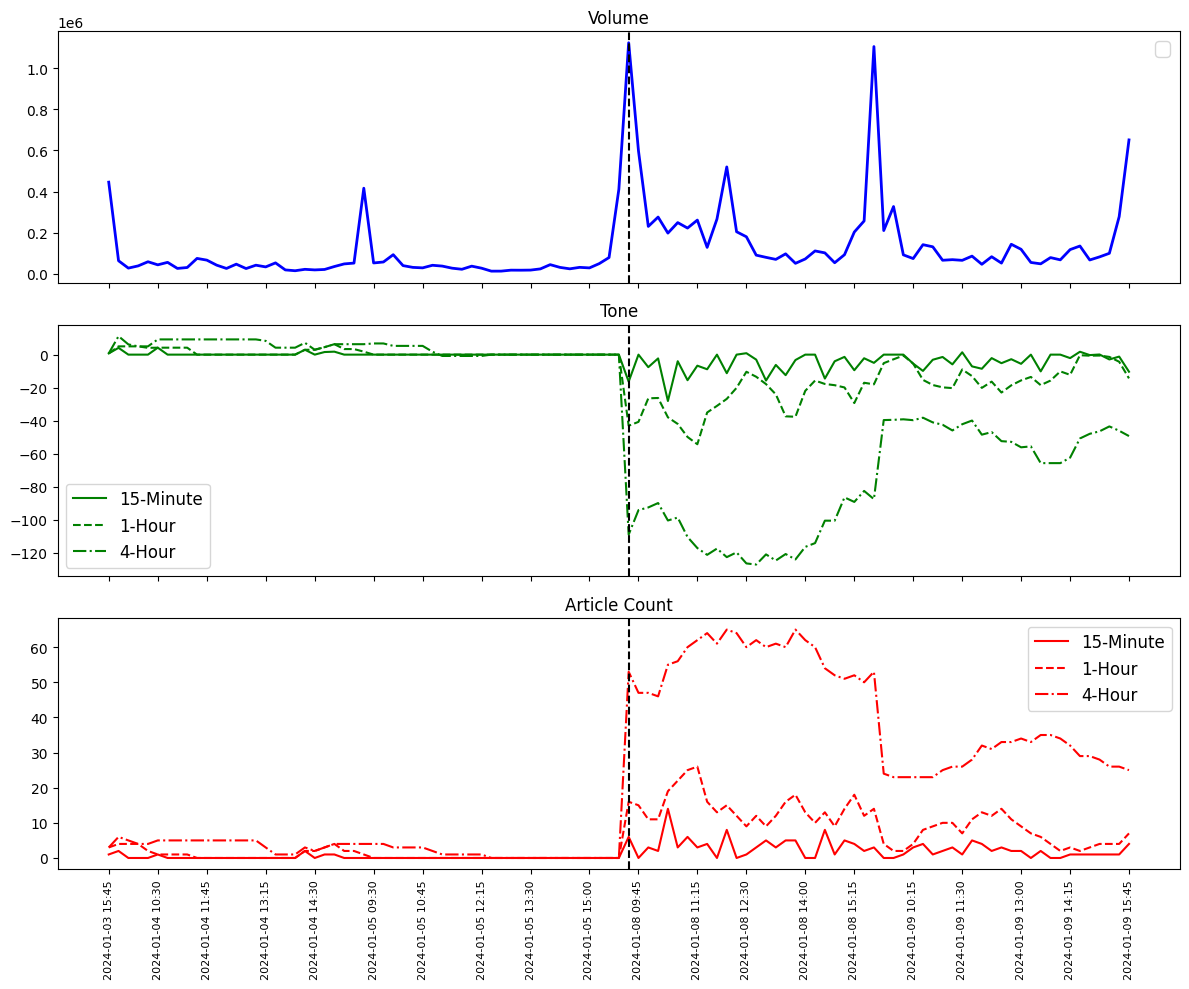

In [58]:
# Event plot for Alaska Airlines (ALK) around the event time of Jan. 6, 2024
event_time = datetime.datetime(2024,1,6,9,30,0)
event_window = 52

plot_data = df[(df['ticker']=='ALK')].reset_index(drop=True)
plot_data.index = plot_data['date']
idx = plot_data.index.get_indexer([event_time], method='nearest')[0]
start_idx = max(0, idx - event_window)
end_idx = min(len(plot_data) - 1, idx + event_window)
df_window = plot_data.iloc[start_idx:end_idx+1].copy()
df_window = df_window.reset_index(drop=True)

# Find the new event index now that the index is reset
idx = df_window[df_window['date'] >= event_time].index[0]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
xticks = np.linspace(0, len(df_window)-1, 20, dtype=int)

axes[0].plot(df_window.index, df_window['Volume'], color='b', linewidth=2)
axes[0].set_title('Volume')
axes[0].axvline(idx, color='black', linestyle='--')
axes[0].legend(fontsize=14)
axes[0].set_xticks(xticks)
axes[0].set_xticklabels([df_window['date'].iloc[x].strftime('%Y-%m-%d %H:%M') for x in xticks], rotation=90, fontsize=8)
axes[1].plot(df_window.index, df_window['Tone_lag01']   , label='15-Minute', color = 'g', linestyle='-' )
axes[1].plot(df_window.index, df_window['Tone_cum04_lag01'], label='1-Hour', color = 'g', linestyle='--')
axes[1].plot(df_window.index, df_window['Tone_cum16_lag01'], label='4-Hour', color = 'g', linestyle='-.')
axes[1].set_title('Tone')
axes[1].axvline(idx, color='black', linestyle='--')
axes[1].legend(fontsize=12)
axes[1].set_xticks(xticks)
axes[1].set_xticklabels([df_window['date'].iloc[x].strftime('%Y-%m-%d %H:%M') for x in xticks], rotation=90, fontsize=8)
axes[2].plot(df_window.index,    df_window['Article Count_lag01'], label='15-Minute', color='r', linestyle='-' )
axes[2].plot(df_window.index, df_window['Article Count_cum04_lag01'], label='1-Hour', color='r', linestyle='--')
axes[2].plot(df_window.index, df_window['Article Count_cum16_lag01'], label='4-Hour', color='r', linestyle='-.')
axes[2].set_title('Article Count')
axes[2].axvline(idx, color='black', linestyle='--')
axes[2].legend(fontsize=12)
axes[2].set_xticks(xticks)
axes[2].set_xticklabels([df_window['date'].iloc[x].strftime('%Y-%m-%d %H:%M') for x in xticks], rotation=90, fontsize=8)

plt.tight_layout()
plt.savefig('../../output/alk_event_plot_52.pdf', bbox_inches='tight')

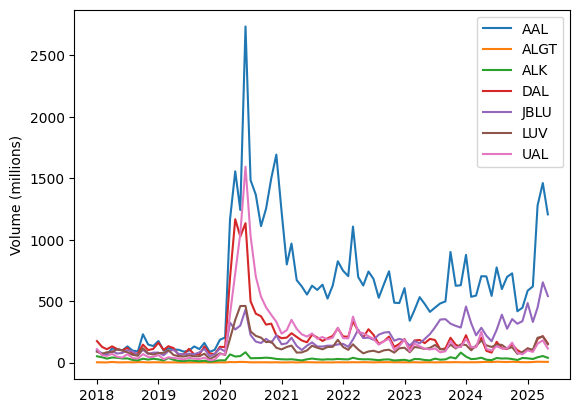

In [15]:
# Plot monthly volume for each ticker
df['month'] = df['date'].dt.to_period('M')
monthly_volume = df.groupby(['month', 'ticker'])['Volume'].sum().reset_index()
monthly_volume['month'] = monthly_volume['month'].dt.to_timestamp()  # Convert Period to Timestamp for plotting
monthly_volume['Volume'] = monthly_volume['Volume'] / 1000000
sns.lineplot(data=monthly_volume, x='month', y='Volume', hue='ticker')
plt.legend(title='')
plt.xlabel('') 
plt.ylabel('Volume (millions)')
plt.savefig('../../output/monthly_volume_plot.pdf', bbox_inches='tight')